In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px


## Import Raw Data

In [3]:
df=pd.read_csv("C:/Users/OM/Desktop/Pizza Sales Analysis/pizza_sales.csv")

## MetaData of Raw Data

In [4]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-15,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-15,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-15,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-15,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-15,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [5]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-15,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-15,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-15,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-15,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-15,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [6]:
print("The MetaData of the Dataset: ",df.shape)

The MetaData of the Dataset:  (48620, 12)


In [7]:
print("The Rows of the Dataset: ",df.shape[0])

The Rows of the Dataset:  48620


In [8]:
print("The Columns of the Dataset: ",df.shape[1])

The Columns of the Dataset:  12


In [9]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


### Data Types in Raw Data

In [11]:
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [12]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


### KPI's

In [13]:
total_revenue = df["total_price"].sum()
total_pizzas_sold = df["quantity"].sum()
total_orders = df["order_id"].nunique()
avg_order_value = total_revenue/total_orders
avg_pizzas_per_order = total_pizzas_sold/total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Pizzas Sold: {total_pizzas_sold:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Avg Order value: ${avg_order_value:,.2f}")
print(f"Avg Pizzas Per Order: {avg_pizzas_per_order:,.2f}")

Total Revenue: $817,860.05
Total Pizzas Sold: 49,574
Total Orders: 21,350
Avg Order value: $38.31
Avg Pizzas Per Order: 2.32


### Charts

#### Ingredient Analysis

In [14]:
ingredient = (
                df['pizza_ingredients'].str.split(",").explode().str.strip().value_counts().reset_index()
                .rename(columns={'index':'Counts','pizza_ingredients':'Ingredients'})
)
print(ingredient.head(16))

          Ingredients  count
0              Garlic  27422
1            Tomatoes  26601
2          Red Onions  19547
3         Red Peppers  16284
4   Mozzarella Cheese  10333
5           Pepperoni  10300
6             Spinach  10012
7           Mushrooms   9624
8             Chicken   8443
9           Capocollo   6572
10       Green Olives   6174
11         Artichokes   5682
12   Jalapeno Peppers   5643
13      Green Peppers   5224
14        Feta Cheese   4748
15          Pineapple   4685


### Daily Trend - Total Orders

C:\Users\OM\AppData\Local\Temp\ipykernel_10452\3886369231.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)


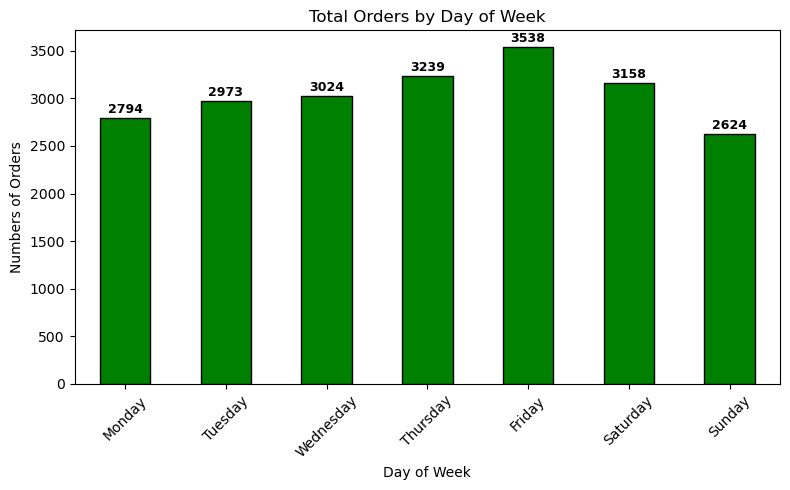

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['day_name'] = df['order_date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = pd.Categorical(df['day_name'],categories=weekday_order,ordered=True)
orders_by_day = df.groupby('day_name',observed=False)['order_id'].nunique()
ax = orders_by_day.plot(kind='bar',figsize=(8,5),color='green',edgecolor='black')

plt.title('Total Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Numbers of Orders')
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
    plt.text(i,val+20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.show()

### Daily Trend - Total Revenue

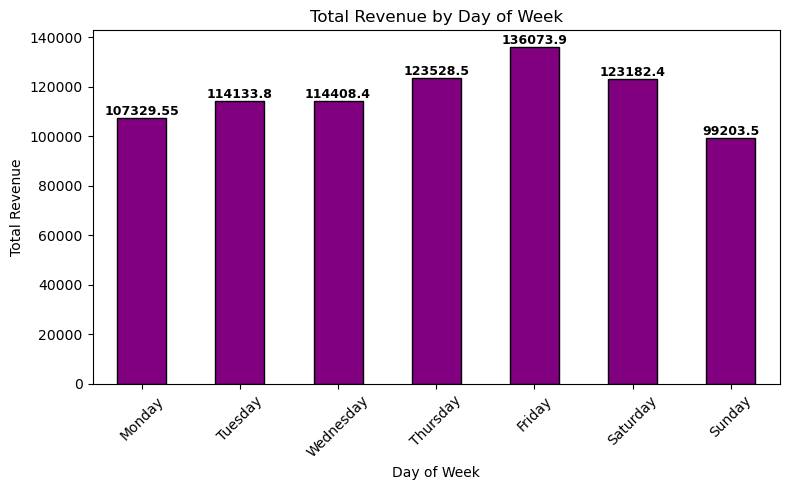

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['day_name'] = df['order_date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = pd.Categorical(df['day_name'],categories=weekday_order,ordered=True)
orders_by_day = df.groupby('day_name',observed=False)['total_price'].sum()
ax = orders_by_day.plot(kind='bar',figsize=(8,5),color='purple',edgecolor='black')

plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
    plt.text(i,val+20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.show()

### Daily Trend - Total Quantity

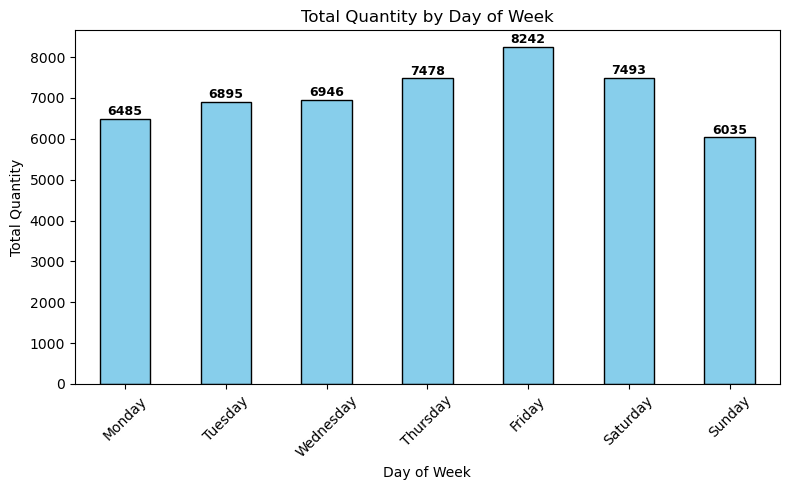

In [17]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['day_name'] = df['order_date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = pd.Categorical(df['day_name'],categories=weekday_order,ordered=True)
orders_by_day = df.groupby('day_name',observed=False)['quantity'].sum()
ax = orders_by_day.plot(kind='bar',figsize=(8,5),color='skyblue',edgecolor='black')

plt.title('Total Quantity by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
    plt.text(i,val+20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.show()

### Hourly Trend - Total Orders

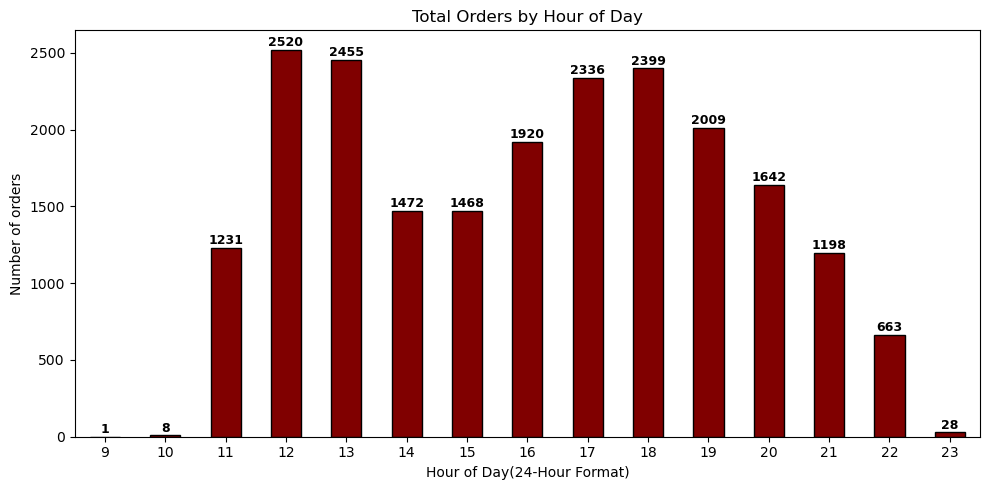

In [22]:
df['order_time'] = pd.to_datetime(df['order_time'],format="%H:%M:%S")
df['order_hour'] = df['order_time'].dt.hour
orders_by_hour = df.groupby('order_hour',observed=False)['order_id'].nunique()
ax = orders_by_hour.plot(kind='bar',figsize=(10,5),color='maroon',edgecolor='black')

plt.title('Total Orders by Hour of Day')
plt.xlabel("Hour of Day(24-Hour Format)")
plt.ylabel("Number of orders")
plt.xticks(rotation=0)

for i,val in enumerate(orders_by_hour):
    plt.text(i,val+5,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')
    
plt.tight_layout()
plt.show()

### Hourly Trend - Total Revenue

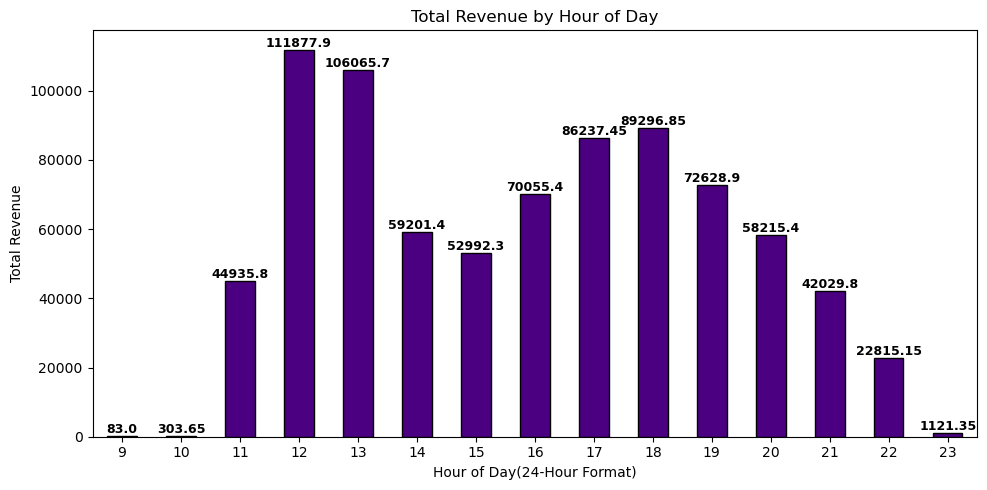

In [27]:
df['order_time'] = pd.to_datetime(df['order_time'],format="%H:%M:%S")
df['order_hour'] = df['order_time'].dt.hour
orders_by_hour = df.groupby('order_hour',observed=False)['total_price'].sum()
ax = orders_by_hour.plot(kind='bar',figsize=(10,5),color='indigo',edgecolor='black')

plt.title('Total Revenue by Hour of Day')
plt.xlabel("Hour of Day(24-Hour Format)")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

for i,val in enumerate(orders_by_hour):
    plt.text(i,val+5,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')
    
plt.tight_layout()
plt.show()

### Hourly Trend - Total Quantity

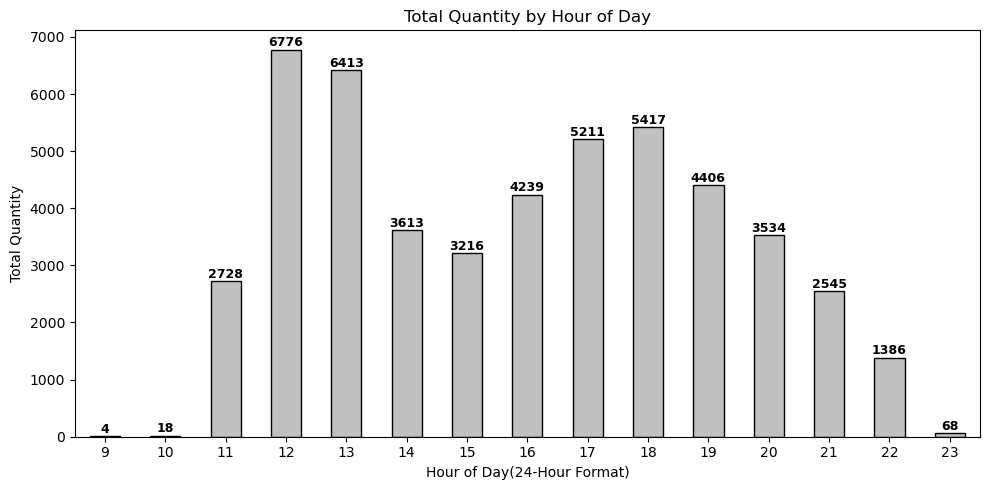

In [28]:
df['order_time'] = pd.to_datetime(df['order_time'],format="%H:%M:%S")
df['order_hour'] = df['order_time'].dt.hour
orders_by_hour = df.groupby('order_hour',observed=False)['quantity'].sum()
ax = orders_by_hour.plot(kind='bar',figsize=(10,5),color='silver',edgecolor='black')

plt.title('Total Quantity by Hour of Day')
plt.xlabel("Hour of Day(24-Hour Format)")
plt.ylabel("Total Quantity")
plt.xticks(rotation=0)

for i,val in enumerate(orders_by_hour):
    plt.text(i,val+5,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')
    
plt.tight_layout()
plt.show()

### Monthly Trend - Total Orders

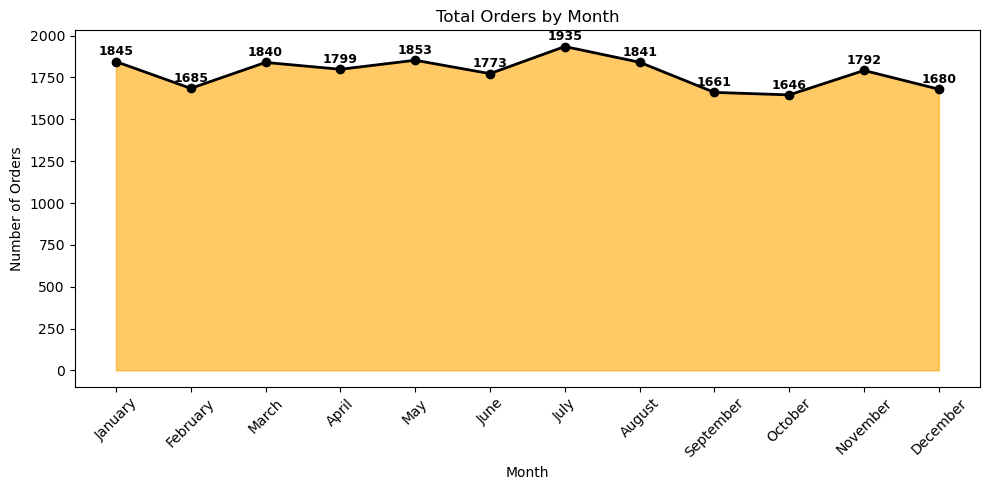

In [34]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['month_name'] = df['order_date'].dt.month_name()
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
df['month_name'] = pd.Categorical(df['month_name'],categories=month_order,ordered=True)
orders_by_month = df.groupby('month_name',observed=False)['order_id'].nunique()

plt.figure(figsize=(10,5))
plt.fill_between(orders_by_month.index,orders_by_month.values,color='orange',alpha=0.6)
plt.plot(orders_by_month.index,orders_by_month.values,color='black',linewidth=2,marker='o')

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_month):
    plt.text(i,val + 20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()

### % of Sales by Category

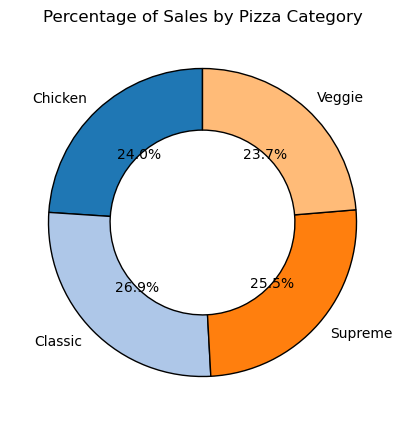

In [37]:
category_sales = df.groupby('pizza_category')['total_price'].sum()
category_pct = category_sales / category_sales.sum()*100

plt.figure(figsize=(5,5))
colors = plt.get_cmap('tab20').colors

plt.pie(category_pct,labels=category_pct.index,autopct='%1.1f%%',startangle=90,colors=colors,wedgeprops={'edgecolor':'black','width':0.4})
plt.title("Percentage of Sales by Pizza Category")
plt.show()

### % of Sales by Pizza Size & Category

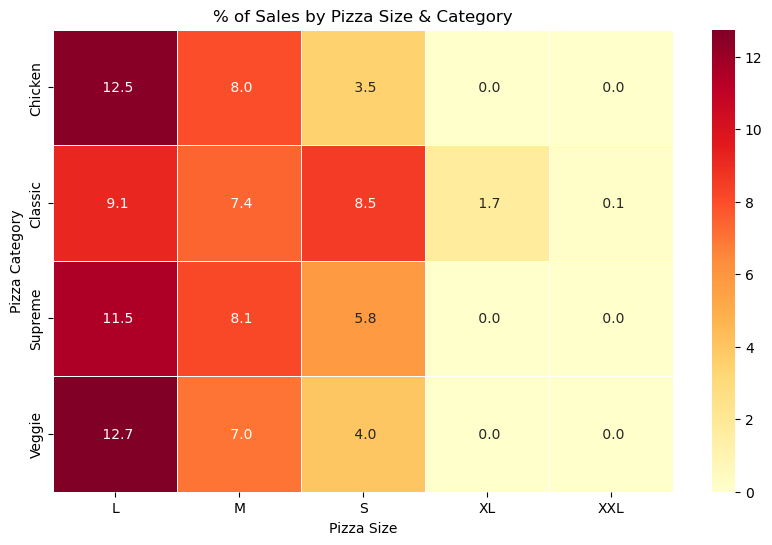

In [45]:
sales_pivot = df.pivot_table(index='pizza_category',columns='pizza_size',values='total_price',aggfunc='sum',fill_value=0)

sales_pct = sales_pivot / sales_pivot.sum().sum()*100

plt.figure(figsize=(10,6))
sns.heatmap(sales_pct,annot=True,fmt=" .1f",cmap="YlOrRd",linewidths=0.5)
plt.title("% of Sales by Pizza Size & Category")
plt.ylabel("Pizza Category")
plt.xlabel("Pizza Size")
plt.show()

### Total Pizzas Sold by Pizza Category

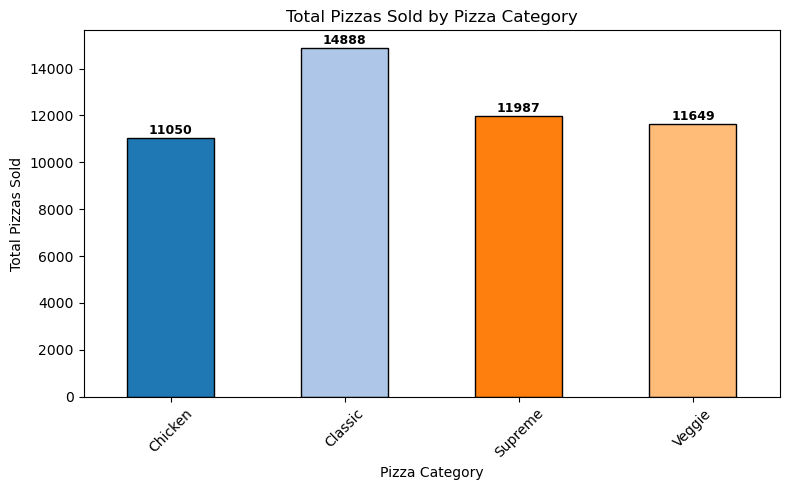

In [46]:
pizzas_by_category = df.groupby('pizza_category')['quantity'].sum()

colors = list(plt.get_cmap('tab20').colors)
colors=colors[:len(pizzas_by_category)]

ax= pizzas_by_category.plot(kind='bar',figsize=(8,5),color=colors,edgecolor='black')
        
plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i,val in enumerate(pizzas_by_category):
    plt.text(i,val + 20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()

### Top 5 Best-Selling Pizzas - Total Quantity

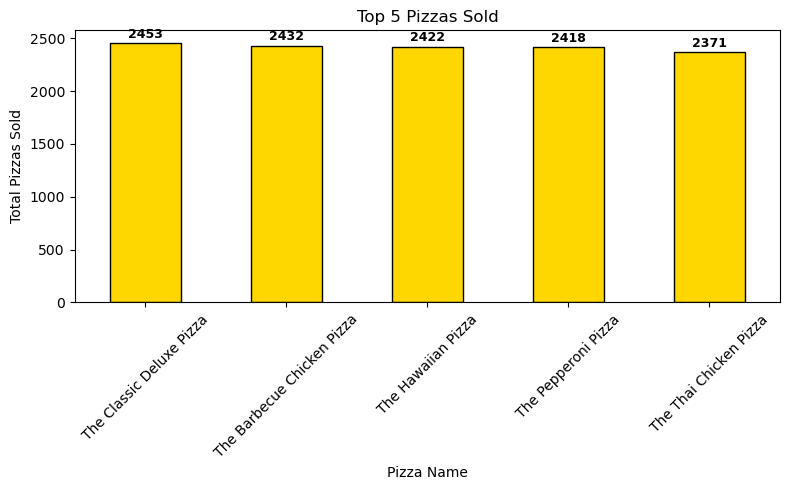

In [50]:
pizzas_by_name = df.groupby('pizza_name')['quantity'].sum()

top5=pizzas_by_name.sort_values(ascending=False).head(5)

ax= top5.plot(kind='bar',figsize=(8,5),color='gold',edgecolor='black')
        
plt.title("Top 5 Pizzas Sold")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i,val in enumerate(top5):
    plt.text(i,val + 20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()

### Top 5 Best-Selling Pizzas - Total Orders

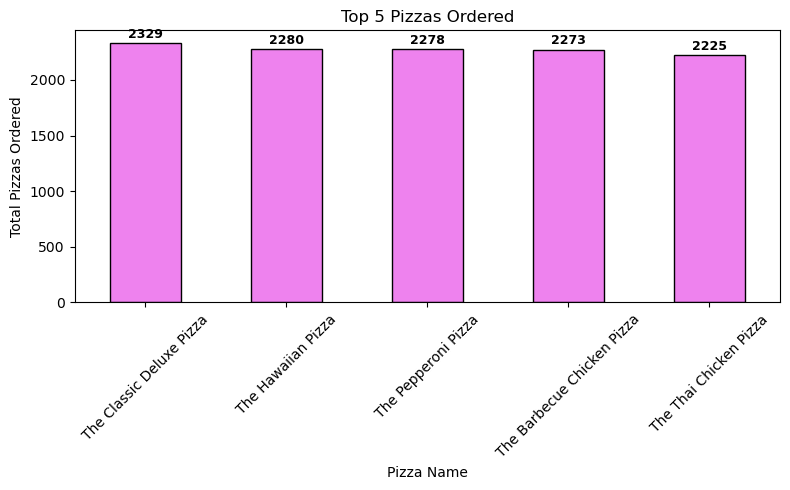

In [53]:
pizzas_by_name = df.groupby('pizza_name')['order_id'].nunique()

top5=pizzas_by_name.sort_values(ascending=False).head(5)

ax= top5.plot(kind='bar',figsize=(8,5),color='violet',edgecolor='black')
        
plt.title("Top 5 Pizzas Ordered")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Ordered")
plt.xticks(rotation=45)

for i,val in enumerate(top5):
    plt.text(i,val + 20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()

### Top 5 Best-Selling Pizzas - Total Sales

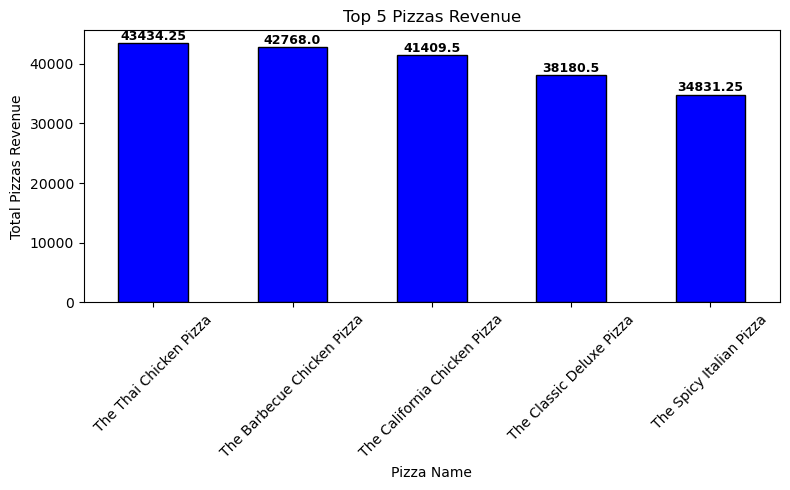

In [56]:
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

top5=pizzas_by_name.sort_values(ascending=False).head(5)

ax= top5.plot(kind='bar',figsize=(8,5),color='blue',edgecolor='black')
        
plt.title("Top 5 Pizzas Revenue")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Revenue")
plt.xticks(rotation=45)

for i,val in enumerate(top5):
    plt.text(i,val + 20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()

### Bottom 5 Least-Selling Pizzas - Total Sales

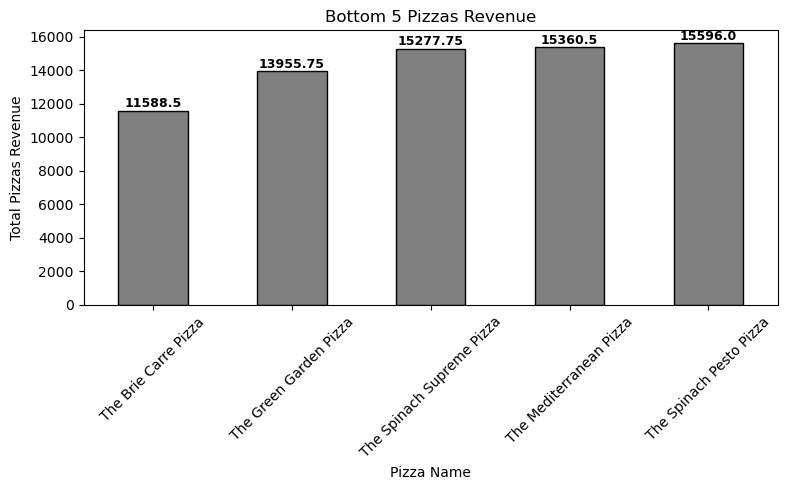

In [59]:
pizzas_by_name = df.groupby('pizza_name')['total_price'].sum()

top5=pizzas_by_name.sort_values(ascending=True).head(5)

ax= top5.plot(kind='bar',figsize=(8,5),color='grey',edgecolor='black')
        
plt.title("Bottom 5 Pizzas Revenue")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Revenue")
plt.xticks(rotation=45)

for i,val in enumerate(top5):
    plt.text(i,val + 20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()